In [1]:
from astropy.table import Table, vstack
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import fitsio
import healpy
from scipy.spatial import cKDTree
from astropy.cosmology import Planck18 as cosmo
from mpl_toolkits.mplot3d import Axes3D
import astropy.units as u
import astropy.constants as const
import matplotlib
import matplotlib.patheffects as pe
from math import log10, floor
import scipy.stats

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [3]:
#load our tables 
L = "40"
R = "1"
figtag = "R"+R+"L"+L
figdir = "figs"+figtag+"/"

In [5]:
sv3elg = Table.read("datafiles/SV3_"+figtag+"_elg.csv",format="csv")
sv3lrg = Table.read("datafiles/SV3_"+figtag+"_lrg.csv",format="csv")

In [4]:
mock0elg = Table.read("datafiles/mock0_"+figtag+"_elg.csv",format="csv")
mock0lrg = Table.read("datafiles/mock0_"+figtag+"_lrg.csv",format="csv")

In [3]:
mockRocherelg = Table.read("datafiles/RocherMock"+figtag+"_elg.csv",format='csv')
mockRocherlrg = Table.read("datafiles/RocherMock"+figtag+"_lrg.csv",format='csv')

In [7]:
mockUchuulrg = Table.read("datafiles/Uchuu_"+figtag+"_lrg.csv",format='csv')

In [12]:
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(5):
    mockselg.append(Table.read("datafiles/MockA"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/MockA"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg_forFA = vstack(mockselg)
combined_lrg_forFA = vstack(mockslrg)

In [ ]:
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(5):
    mockselg.append(Table.read("datafiles/forFA"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/forFA"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg = vstack(mockselg)
combined_lrg = vstack(mockslrg)

In [9]:
#Calculate error in our estimate of CiC with bootstrap method

sv3elg_ros = [sv3elg[(sv3elg['rosette'] == i)] for i in np.arange(1,21)]
sv3lrg_ros = [sv3lrg[(sv3lrg['rosette'] == i)] for i in np.arange(1,21)]
binmax=24

#1D histograms
bins = np.arange(-0.5,binmax+0.5,step=1)
sv3elg_roshist = np.array([np.histogram(sv3elg_ros[i]["N_CiC"], bins = bins,
                                        density = True) for i in range(20)])
sv3lrg_roshist = np.array([np.histogram(sv3lrg_ros[i]["N_CiC"], bins = bins,
                                        density = True) for i in range(20)])

sv3elglrg_roshist = np.array([np.histogram(sv3elg_ros[i]["N_lrgCiC"], bins = bins,
                                           density = True) for i in range(20)])
sv3lrgelg_roshist = np.array([np.histogram(sv3lrg_ros[i]["N_elgCiC"], bins = bins,
                                           density = True) for i in range(20)])
#first index: rosette number
#second index: 

sv3elg_CiCerr = [np.std([sv3elg_roshist[j,0][i] for j in np.arange(20)]) for i in np.arange(binmax)]
sv3lrg_CiCerr = [np.std([sv3lrg_roshist[j,0][i] for j in np.arange(20)]) for i in np.arange(binmax)]

sv3elglrg_CiCerr = [np.std([sv3elglrg_roshist[j,0][i] for j in np.arange(20)]) for i in np.arange(binmax)]
sv3lrgelg_CiCerr = [np.std([sv3lrgelg_roshist[j,0][i] for j in np.arange(20)]) for i in np.arange(binmax)]

#2D histograms
elgmultitracer_roshist = [np.histogram2d(sv3elg_ros[i]["N_lrgCiC"],sv3elg_ros[i]["N_CiC"], 
                                          density=True,bins=bins) for i in range(20)]
lrgmultitracer_roshist = [np.histogram2d(sv3lrg_ros[i]["N_CiC"],sv3lrg_ros[i]["N_elgCiC"], 
                                          density=True,bins=bins) for i in range(20)]
#first index: rosette number
#second index: 0 to get histogram data
#third index: lrg CiC
#fourth index: elg CiC
elgmultitracer_CiCerr = [[np.std([elgmultitracer_roshist[i][0][j,k] for i in range(20)]) for k in range(binmax)] \
                         for j in range(binmax)]
lrgmultitracer_CiCerr = [[np.std([lrgmultitracer_roshist[i][0][j,k] for i in range(20)]) for k in range(binmax)] \
                         for j in range(binmax)]
#output array: 
# first index: lrg CiC
# second index: elg CiC
print(elgmultitracer_CiCerr[3][0])
print(elgmultitracer_CiCerr[3][1])

0.0005634148101257451
0.00029259198825203276


/tmp/ipykernel_839550/3568920487.py:9: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sv3elg_roshist = np.array([np.histogram(sv3elg_ros[i]["N_CiC"], bins = bins,
/tmp/ipykernel_839550/3568920487.py:11: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sv3lrg_roshist = np.array([np.histogram(sv3lrg_ros[i]["N_CiC"], bins = bins,
/tmp/ipykernel_839550/3568920487.py:14: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you me

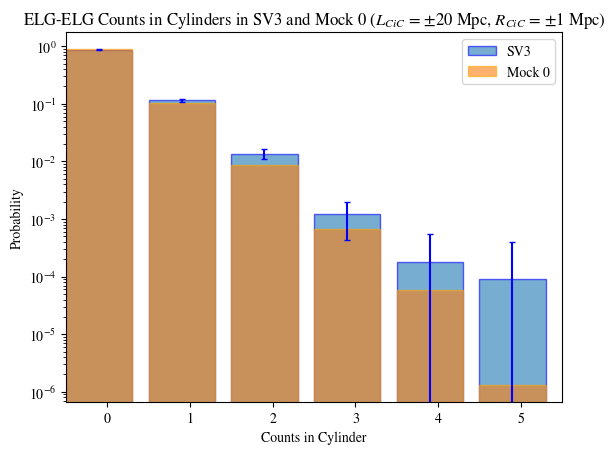

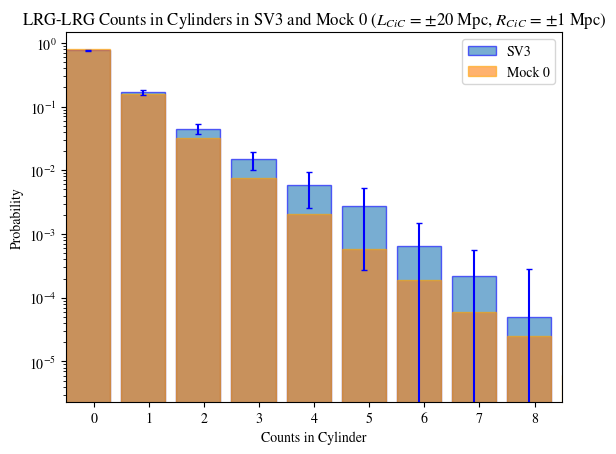

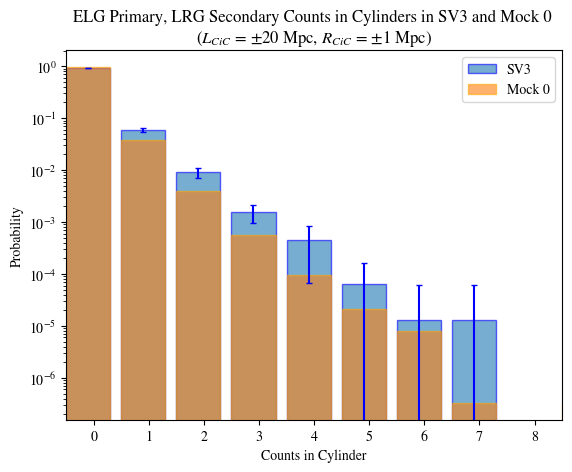

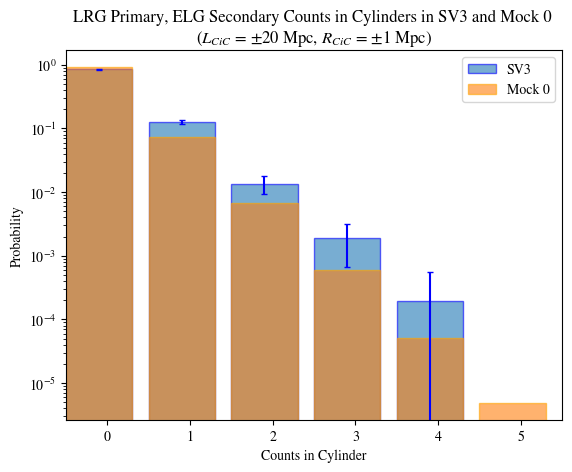

In [50]:
#make plots of all ELG-ELG distributions
binmax = 24
fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title(r"ELG-ELG Counts in Cylinders in SV3 and Mock 0 ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3elg["N_CiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3elg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(mock0elg["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mock 0",alpha=0.6,align='edge',edgecolor='orange')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,5.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"ELG_ELG_mockandSV3"+figtag+".png")





fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title(r"LRG-LRG Counts in Cylinders in SV3 and Mock 0 ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3lrg["N_CiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3lrg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(mock0lrg["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mock 0",alpha=0.6,align='edge',edgecolor='orange')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,8.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"LRG_LRG_mockandSV3"+figtag+".png")




fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title("ELG Primary, LRG Secondary Counts in Cylinders in SV3 and Mock 0 \n"+ r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3elg["N_lrgCiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3elglrg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(mock0elg["N_lrgCiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mock 0",alpha=0.6,align='edge',edgecolor='orange')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,8.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"ELG_LRG_mockandSV3"+figtag+".png")



fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title("LRG Primary, ELG Secondary Counts in Cylinders in SV3 and Mock 0 \n" +r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3lrg["N_elgCiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3lrgelg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(mock0lrg["N_elgCiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mock 0",alpha=0.6,align='edge',edgecolor='orange')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,5.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"LRG_ELG_mockandSV3"+figtag+".png")

/tmp/ipykernel_1020886/2054870907.py:8: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1020886/2054870907.py:8: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1020886/2054870907.py:11: RuntimeWarning: divide by zero encountered in log
  cbar = plt.colorbar(pc,ticks = np.log(np.arange(13)))
/tmp/ipykernel_1020886/2054870907.py:20: RuntimeWarning: invalid value encountered in double_scalars
  elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]


0.00033395843501939527
7.706733115832198e-05
0.0


/tmp/ipykernel_1020886/2054870907.py:42: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1020886/2054870907.py:42: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1020886/2054870907.py:45: RuntimeWarning: divide by zero encountered in log
  cbar = plt.colorbar(pc,ticks = np.log(np.arange(13)))


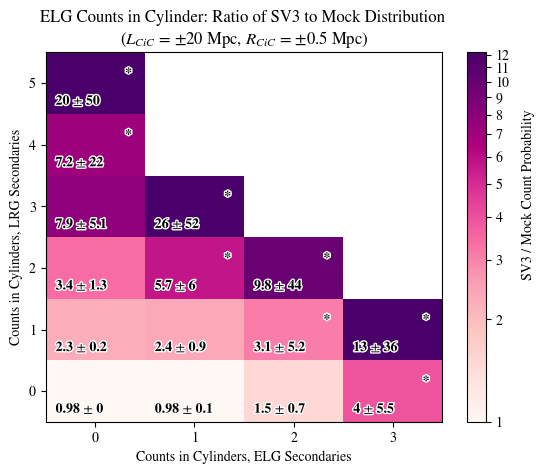

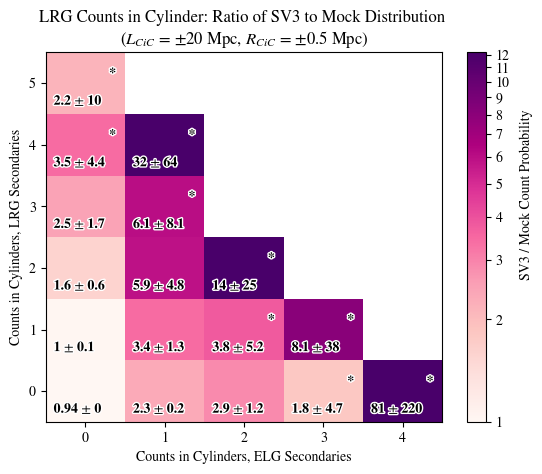

In [41]:
def round_to_2(x):
    return round(np.round(x,decimals=1), -int(floor(log10(x))-1))


maxcounts = 9
hist1,binsx,binsy = np.histogram2d(sv3elg["N_lrgCiC"],sv3elg["N_CiC"], density=True,bins=bins)
hist2,binsx,binsy = np.histogram2d(mock0elg["N_lrgCiC"],mock0elg["N_CiC"], density=True,bins=bins)
diff = np.log(hist1)-np.log(hist2)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,diff,vmax=2.5,vmin=0,cmap='RdPu')
cbar = plt.colorbar(pc,ticks = np.log(np.arange(13)))
cbar.ax.set_yticklabels([str(i) for i in np.arange(13)])
ax.set_title("ELG Counts in Cylinder: Ratio of SV3 to Mock Distribution \n" + r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")
ax.set_xlabel("Counts in Cylinders, ELG Secondaries")
ax.set_ylabel("Counts in Cylinders, LRG Secondaries")
ax.set_xlim(-0.5,maxcounts+0.5)
ax.set_ylim(-0.5,maxcounts+0.5)
ax.set_xticks(np.arange(0,6),labels=[str(i) for i in np.arange(0,6)])

elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]
                              for i in range(maxcounts+1)])
for (i, j), z in np.ndenumerate(np.exp(diff[:maxcounts+1,:maxcounts+1])):
    if z > 0:
        ax.text((j+0.1)-0.5, (i+0.1)-0.5, '{:.2g}'.format(z)+r" $\pm$ "+'{:g}'.format(round_to_2(elgmultitracer_CiCerr[i][j]/hist2[i][j])), ha='left', va='bottom',
                color='black',path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight=600)
        if z < elgmultitracer_CiCerr[i][j]/hist2[i][j]:
            ax.text(j+0.8-0.5,i+0.6-0.5,"*",color='black',path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight = 600)
    
ax.text(4.4, maxcounts*0.2, "SV3 / Mock Count Probability",rotation=90, rotation_mode='anchor',transform_rotates_text=True)

plt.xlim(-0.5,3.5)
plt.ylim(-0.5,5.5)
plt.savefig(figdir+"SV3MockRatioELG.png")
print(hist1[3][0])
print(hist1[3][1])
print(hist1[3][2])



hist1,binsx,binsy = np.histogram2d(sv3lrg["N_CiC"],sv3lrg["N_elgCiC"], density=True,bins=bins)
hist2,binsx,binsy = np.histogram2d(mock0lrg["N_CiC"],mock0lrg["N_elgCiC"], density=True,bins=bins)
diff = np.log(hist1)-np.log(hist2)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,diff,vmax=2.5,vmin=0,cmap='RdPu')
cbar = plt.colorbar(pc,ticks = np.log(np.arange(13)))
cbar.ax.set_yticklabels([str(i) for i in np.arange(13)])
ax.set_title("LRG Counts in Cylinder: Ratio of SV3 to Mock Distribution \n" + r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")
ax.set_xlabel("Counts in Cylinders, ELG Secondaries")
ax.set_ylabel("Counts in Cylinders, LRG Secondaries")
ax.set_xlim(-0.5,4+0.5)
ax.set_ylim(-0.5,5+0.5)
ax.set_xticks(np.arange(0,5),labels=[str(i) for i in np.arange(0,5)])

for (i, j), z in np.ndenumerate(np.exp(diff[:maxcounts+1,:maxcounts+1])):
    if z > 0:
        ax.text((j+0.1)-0.5, (i+0.1)-0.5, '{:.2g}'.format(z)+r" $\pm$ "+'{:g}'.format(round_to_2(lrgmultitracer_CiCerr[i][j]/hist2[i][j])), ha='left', va='bottom',
                color='black',path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight=600)
        if z < lrgmultitracer_CiCerr[i][j]/hist2[i][j]:
            ax.text(j+0.8-0.5,i+0.6-0.5,"*",color='black',path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight = 600)
    
ax.text(5.6, maxcounts*0.2, "SV3 / Mock Count Probability",rotation=90, rotation_mode='anchor',transform_rotates_text=True)
plt.savefig(figdir+"SV3MockRatioLRG.png")

<Figure size 640x480 with 0 Axes>

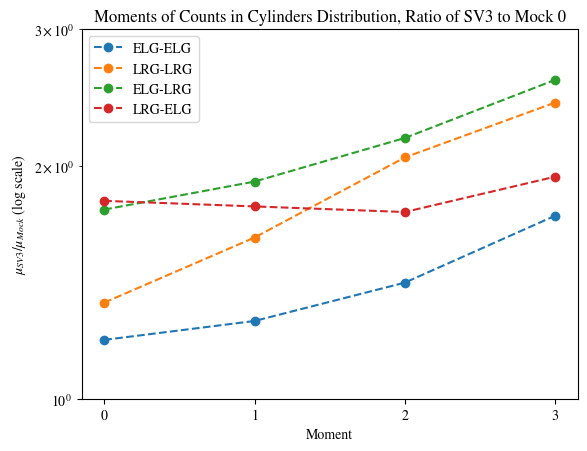

In [19]:
#Find Moments of CiC distributions
def moments(dist1,dist2,n):
    titles = ["First","Second",'Third','Fourth','Fifth','Sixth']
    print(titles[0]+" Moment")
    print("SV3: "+"{:.4g}".format(np.mean(dist1))+", Mock: "+"{:.4g}".format(np.mean(dist2)))
    for i in np.arange(1,n):
        mom1 = scipy.stats.moment(dist1,moment = (i+1))
        mom2 = scipy.stats.moment(dist2,moment = (i+1))
        print(titles[i]+" Moment")
        print("SV3: "+"{:.4g}".format(mom1)+", Mock: "+"{:.4g}".format(mom2))

dist1s = [sv3elg["N_CiC"], sv3lrg['N_CiC'],sv3elg['N_lrgCiC'],sv3lrg['N_elgCiC']]
dist2s = [mock0elg["N_CiC"], mock0lrg['N_CiC'],mock0elg['N_lrgCiC'],mock0lrg['N_elgCiC']]
names = ["ELG","LRG","ELG-LRG","LRG-ELG"]
'''for i in range(len(dists)):
    print(names[i])
    moments(dist1s[i],dist2s[i],4)'''

    
plt.figure()
fig,ax = plt.subplots(1)
plt.ylim(1,3)
legends = ["ELG-ELG","LRG-LRG",'ELG-LRG','LRG-ELG']
nmoments = 4
mom_err = [[[] for j in range(nmoments)] for i in range(4)]


for i in range(4):
    dist1moments = [np.mean(dist1s[i])]
    dist2moments = [np.mean(dist2s[i])]
    for j in range(nmoments):
        dist1moments.append(scipy.stats.moment(dist1s[i],moment = (j+2)))
        dist2moments.append(scipy.stats.moment(dist2s[i],moment = (j+2)))

    plt.plot(np.arange(nmoments),[dist1moments[j]/dist2moments[j] for j in range(nmoments)],'--o',label=legends[i])
    plt.legend()
    plt.yscale('log')
    
ax.set_xticks([0,1,2,3])    
plt.xlabel("Moment")
plt.ylabel(r"$\mu_{SV3}$/$\mu_{Mock}$ (log scale)")
plt.title("Moments of Counts in Cylinders Distribution, Ratio of SV3 to Mock 0")
plt.savefig(figdir+"moments.png")

## Comparison with Rocher Mock ##

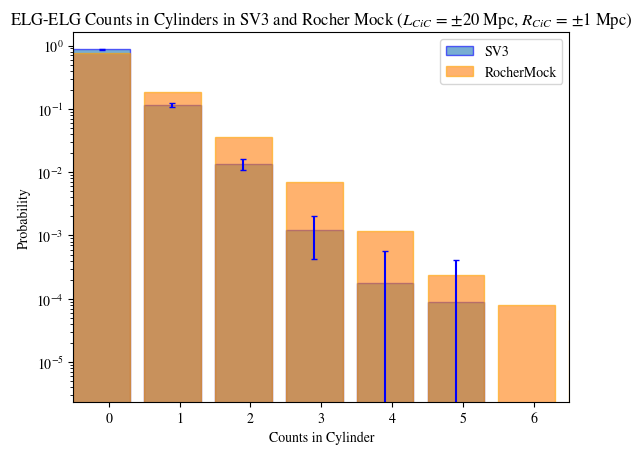

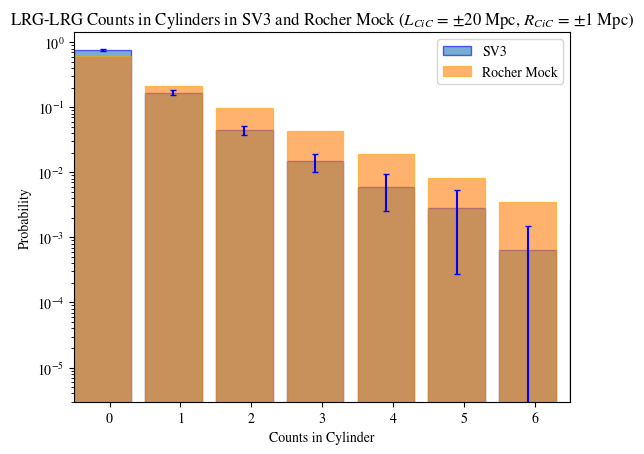

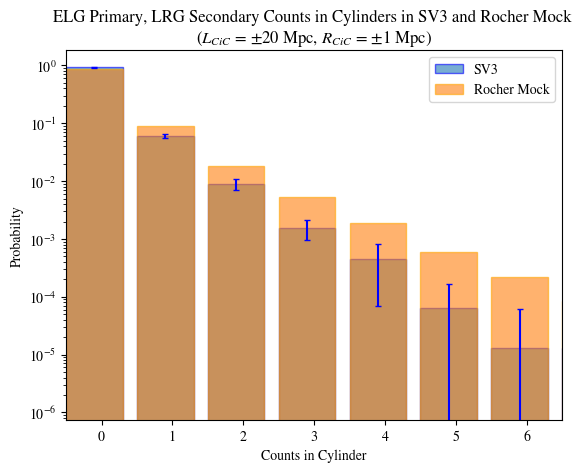

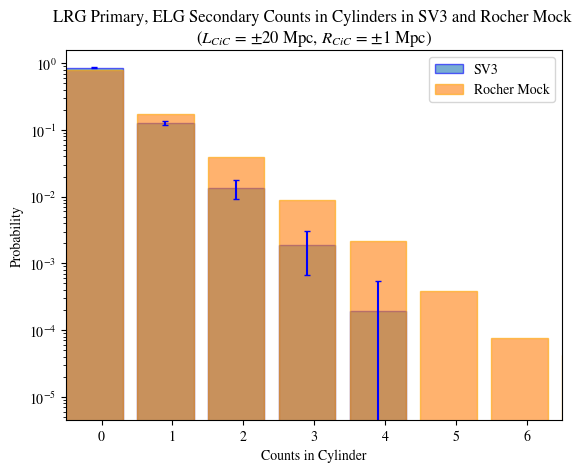

In [9]:
#make plots of all ELG-ELG distributions
binmax = 24
fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title(r"ELG-ELG Counts in Cylinders in SV3 and Rocher Mock ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3elg["N_CiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3elg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(mockRocherelg["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="RocherMock",alpha=0.6,align='edge',edgecolor='orange')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,6.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"ELG_ELG_RocherandSV3"+figtag+".png")





fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title(r"LRG-LRG Counts in Cylinders in SV3 and Rocher Mock ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3lrg["N_CiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3lrg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(mockRocherlrg["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Rocher Mock",alpha=0.6,align='edge',edgecolor='orange')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,6.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"LRG_LRG_RocherandSV3"+figtag+".png")




fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title("ELG Primary, LRG Secondary Counts in Cylinders in SV3 and Rocher Mock \n"+ r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3elg["N_lrgCiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3elglrg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(mockRocherelg["N_lrgCiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Rocher Mock",alpha=0.6,align='edge',edgecolor='orange')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,6.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"ELG_LRG_RocherandSV3"+figtag+".png")



fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title("LRG Primary, ELG Secondary Counts in Cylinders in SV3 and Rocher Mock \n" +r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3lrg["N_elgCiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3lrgelg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(mockRocherlrg["N_elgCiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Rocher Mock",alpha=0.6,align='edge',edgecolor='orange')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,6.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"LRG_ELG_RocherandSV3"+figtag+".png")

In [13]:
x = [1,2,3]
print(x[:2])

[1, 2]


In [71]:
a=[0]
a.append(1)
print(a)

[0, 1]


## Idea for Weighted Distributions ##

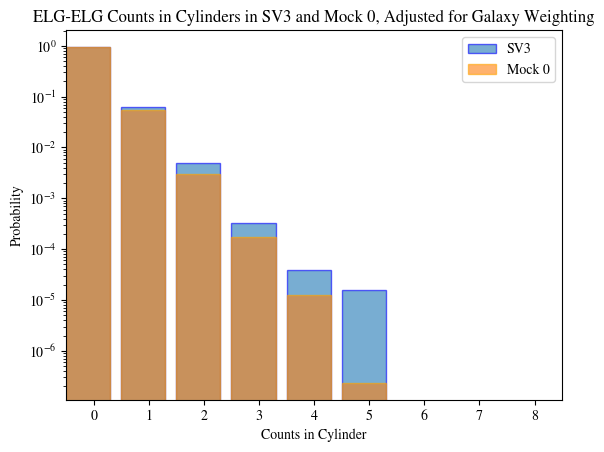

In [35]:
binmax = 24
fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title(r"ELG-ELG Counts in Cylinders in SV3 and Mock 0, Adjusted for Galaxy Weighting")
def w(N):
    return 1/(N+1)
sv3hist, bins1 = np.histogram(sv3elg["N_CiC"], bins = bins, density = True, weights = [w(N) for N in sv3elg["N_CiC"]])
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(mock0elg["N_CiC"], bins = bins, density = True, weights = [w(N) for N in mock0elg["N_CiC"]])
plt.bar(bins1[:-1], mockhist, label="Mock 0",alpha=0.6,align='edge',edgecolor='orange')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,8.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"ELG_ELG_mockandSV3"+figtag+".png")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[0.041666666666666664, 0.034713496760889424, 0.029467314511446668, 0.026333659640374724, 0.023476522463076268]
[0.041666666666666664, 0.03534340750347007, 0.030316590656248674, 0.02734880900887236, 0.02461328923814998]


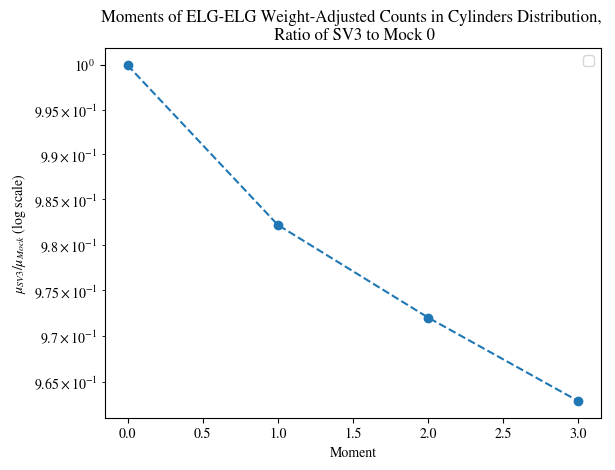

In [38]:
dist1moments = [np.mean(sv3elg["N_CiC"])]
dist2moments = [np.mean(mock0elg["N_CiC"])]
for j in range(nmoments):
    dist1moments.append(scipy.stats.moment(sv3elg["N_CiC"],moment = (j+2)))
    dist2moments.append(scipy.stats.moment(mock0elg["N_CiC"],moment = (j+2)))

plt.plot(np.arange(nmoments),[dist1moments[j]/dist2moments[j] for j in range(nmoments)],'--o')
plt.legend()
plt.xlabel("Moment")
plt.ylabel(r"$\mu_{SV3}$/$\mu_{Mock}$ (log scale)")
plt.yscale('log')
plt.title("Moments of ELG-ELG Weight-Adjusted Counts in Cylinders Distribution, \n Ratio of SV3 to Mock 0")

print(dist1moments)
print(dist2moments)

## Angular Cut Mock Results ##

In [ ]:
#make plots of all ELG-ELG distributions
binmax = 24

alpha = 0.5
fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title(r"ELG-ELG Counts in Cylinders in SV3 and Mock 0 ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3elg["N_CiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3elg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(combined_elg["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mocks with angular cut",alpha=alpha,align='edge',edgecolor='orange')

mockhist, bins1 = np.histogram(mock0elg["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mock 0, no angular cut",alpha=alpha,align='edge',edgecolor='green')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,5.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"ELG_ELG_mockandSV3andCombined"+figtag+".png")





fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title(r"LRG-LRG Counts in Cylinders in SV3 and Mock 0 ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3lrg["N_CiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3lrg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(combined_lrg["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mocks with angular cut",alpha=alpha,align='edge',edgecolor='orange')

mockhist, bins1 = np.histogram(mock0lrg["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mock 0, no angular cut",alpha=alpha,align='edge',edgecolor='green')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,8.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"LRG_LRG_mockandSV3andCombined"+figtag+".png")




fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title("ELG Primary, LRG Secondary Counts in Cylinders in SV3 and Mock 0 \n"+ r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3elg["N_lrgCiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3elglrg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(combined_elg["N_lrgCiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mocks with angular cut",alpha=alpha,align='edge',edgecolor='orange')


mockhist, bins1 = np.histogram(mock0elg["N_lrgCiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mock 0, no angular cut",alpha=alpha,align='edge',edgecolor='green')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,8.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"ELG_LRG_mockandSV3andCombined"+figtag+".png")



fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title("LRG Primary, ELG Secondary Counts in Cylinders in SV3 and Mock 0 \n" +r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3lrg["N_elgCiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3lrgelg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(combined_lrg["N_elgCiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mocks with angular cut",alpha=alpha,align='edge',edgecolor='orange')

mockhist, bins1 = np.histogram(mock0lrg["N_elgCiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mock 0, no angular cut",alpha=alpha,align='edge',edgecolor='green')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,5.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"LRG_ELG_mockandSV3andCombined"+figtag+".png")

# Uchuu Mocks #

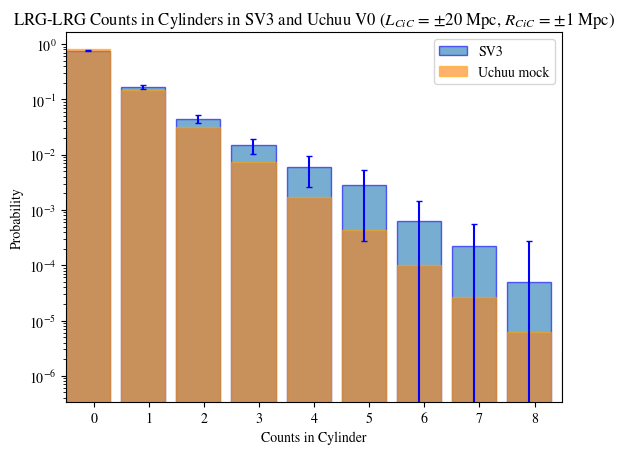

In [14]:
alpha = 0.6
fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title(r"LRG-LRG Counts in Cylinders in SV3 and Uchuu V0 ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3lrg["N_CiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=alpha, yerr = sv3lrg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(mockUchuulrg["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Uchuu mock",alpha=alpha,align='edge',edgecolor='orange')


plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,8.5)

plt.legend()
plt.yscale("log")
plt.savefig(figdir+"LRG_LRG_Uchuu"+figtag+".png")

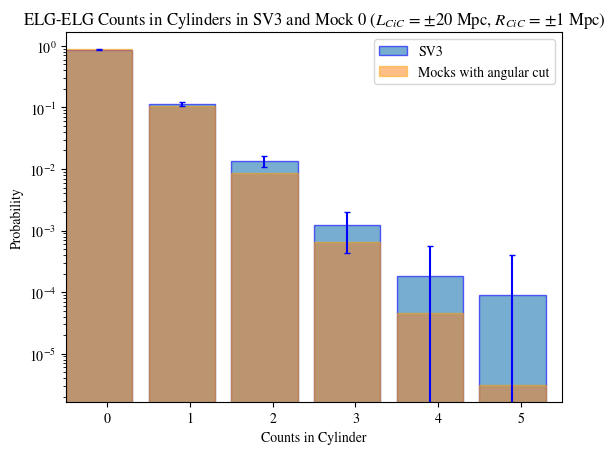

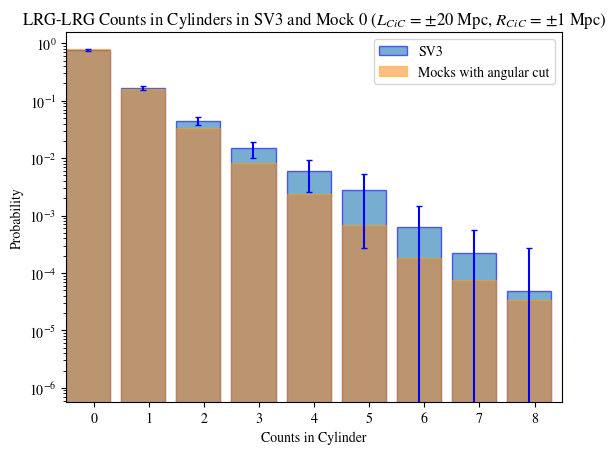

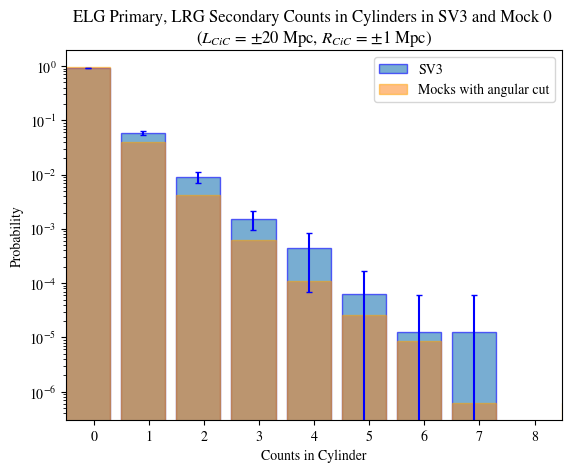

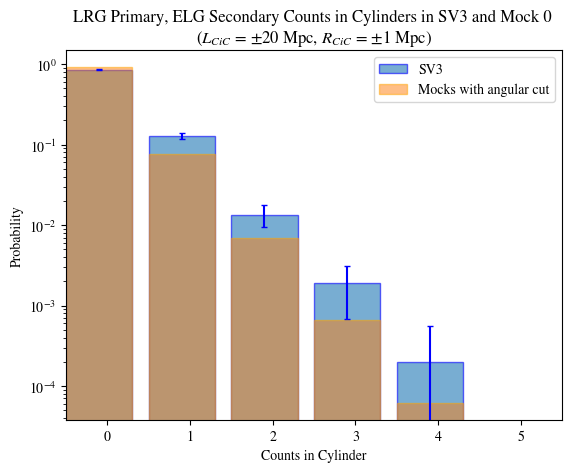

In [13]:
#make plots of all ELG-ELG distributions
binmax = 24

alpha = 0.5
fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title(r"ELG-ELG Counts in Cylinders in SV3 and Mock 0 ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3elg["N_CiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3elg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(combined_elg_forFA["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mocks with angular cut",alpha=alpha,align='edge',edgecolor='orange')


plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,5.5)

plt.legend()
plt.yscale("log")
#plt.savefig(figdir+"ELG_ELG_SV3andCombined"+figtag+".png")





fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title(r"LRG-LRG Counts in Cylinders in SV3 and Mock 0 ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3lrg["N_CiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3lrg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(combined_lrg_forFA["N_CiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mocks with angular cut",alpha=alpha,align='edge',edgecolor='orange')


plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,8.5)

plt.legend()
plt.yscale("log")
#plt.savefig(figdir+"LRG_LRG_mockandSV3andCombined"+figtag+".png")




fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title("ELG Primary, LRG Secondary Counts in Cylinders in SV3 and Mock 0 \n"+ r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3elg["N_lrgCiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3elglrg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(combined_elg_forFA["N_lrgCiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mocks with angular cut",alpha=alpha,align='edge',edgecolor='orange')


plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,8.5)

plt.legend()
plt.yscale("log")
#plt.savefig(figdir+"ELG_LRG_mockandSV3andCombined"+figtag+".png")



fig,ax = plt.subplots(1)
ax.set_xticks(bins+0.5)
plt.title("LRG Primary, ELG Secondary Counts in Cylinders in SV3 and Mock 0 \n" +r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

sv3hist, bins1 = np.histogram(sv3lrg["N_elgCiC"], bins = bins, density = True)
plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3lrgelg_CiCerr,align='edge',
        edgecolor='blue',ecolor='blue',capsize=2)

mockhist, bins1 = np.histogram(combined_lrg_forFA["N_elgCiC"], bins = bins, density = True)
plt.bar(bins1[:-1], mockhist, label="Mocks with angular cut",alpha=alpha,align='edge',edgecolor='orange')

plt.xlabel("Counts in Cylinder")
plt.ylabel("Probability")
plt.xlim(-0.5,5.5)

plt.legend()
plt.yscale("log")
#plt.savefig(figdir+"LRG_ELG_mockandSV3andCombined"+figtag+".png")